# GPN-MSA: basic example

## Setup

In [1]:
from gpn.data import GenomeMSA, Tokenizer
import gpn.model
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import torch
from transformers import AutoModel, AutoModelForMaskedLM

In [2]:
model_path = "../MSA-BERT-Checkpoint"  # path to the model checkpoint
# see README in https://huggingface.co/datasets/songlab/multiz100way for faster queries

# download the MSA dataset from https://huggingface.co/datasets/songlab/multiz100way/resolve/main/89.zarr.zip and provide the path
msa_path = "../analysis/89.zarr"

## Loading data

Example region: chr6:31575665-31575793

[UCSC Genome Browser view](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hg38&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr6%3A31575665%2D31575793&hgsid=1726885238_vIMnX2NGEluaKCXVZjeTkj97aydM) 

In [3]:
genome_msa = GenomeMSA(msa_path, in_memory=False)  # can take a minute or two

Loading MSA...
Loading MSA... Done


/home/david/.conda/envs/msa_gpn/lib/python3.11/site-packages/zarr/core/group.py:3301: UserWarning: Object at .snakemake_timestamp is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [4]:
# untokenized msa
raw_msa = genome_msa.get_msa("6", 31575665, 31575793, strand="+", tokenize=False)
print(raw_msa.shape)
raw_msa

(128, 90)


array([[b'A', b'A', b'-', ..., b'-', b'-', b'-'],
       [b'C', b'G', b'-', ..., b'-', b'-', b'-'],
       [b'A', b'A', b'A', ..., b'-', b'-', b'-'],
       ...,
       [b'T', b'T', b'T', ..., b'-', b'-', b'-'],
       [b'C', b'T', b'C', ..., b'-', b'-', b'-'],
       [b'C', b'C', b'C', ..., b'-', b'-', b'-']],
      shape=(128, 90), dtype='|S1')

In [5]:
# tokenized msa
msa = genome_msa.get_msa("6", 31575665, 31575793, strand="+", tokenize=True)
msa

array([[1, 1, 0, ..., 0, 0, 0],
       [2, 3, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [4, 4, 4, ..., 0, 0, 0],
       [2, 4, 2, ..., 0, 0, 0],
       [2, 2, 2, ..., 0, 0, 0]], shape=(128, 90), dtype=uint8)

In [6]:
msa = torch.tensor(np.expand_dims(msa, 0).astype(np.int64))
msa

tensor([[[1, 1, 0,  ..., 0, 0, 0],
         [2, 3, 0,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [4, 4, 4,  ..., 0, 0, 0],
         [2, 4, 2,  ..., 0, 0, 0],
         [2, 2, 2,  ..., 0, 0, 0]]])

In [7]:
# separating human from rest of species
input_ids, aux_features = msa[:, :, 0], msa[:, :, 1:]
input_ids.shape, aux_features.shape

(torch.Size([1, 128]), torch.Size([1, 128, 89]))

## Masked language modeling

In [8]:
model_for_mlm = AutoModelForMaskedLM.from_pretrained(model_path)
model_for_mlm.eval();

In [9]:
raw_msa[76:79, 0]  # Start codon

array([b'A', b'T', b'G'], dtype='|S1')

In [10]:
tokenizer = Tokenizer()
pos = 76  # Let's mask the A and check the model predictions
input_ids[0, pos] = tokenizer.mask_token_id()

In [11]:
input_ids
with torch.no_grad():
    all_logits = model_for_mlm(input_ids=input_ids, aux_features=aux_features).logits
all_logits.shape

torch.Size([1, 128, 6])

In [12]:
nucleotides = list("ACGT")
logits = all_logits[0, pos, [tokenizer.vocab.index(nc) for nc in nucleotides]]
logits

tensor([ 7.0463, -1.9189, -0.3999, -1.3517])

In [13]:
probs = torch.nn.functional.softmax(logits, dim=0).numpy()
probs

array([9.9906415e-01, 1.2766445e-04, 5.8311637e-04, 2.2511378e-04],
      dtype=float32)

<Axes: xlabel='nucleotide', ylabel='probability'>

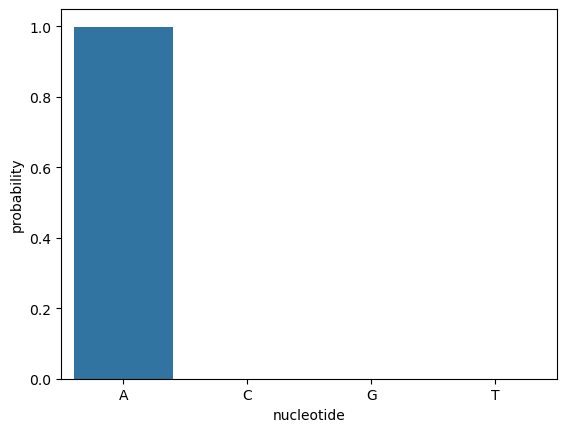

In [14]:
probs_df = pd.DataFrame(dict(nucleotide=nucleotides, probability=probs))
sns.barplot(data=probs_df, x="nucleotide", y="probability")